# Detection of Artificially Generated Texts (30)

Применяем техники из основного задания (частотный анализ, закон Ципфа, закон Хипса, коллокации, морфологическая обработка) к задаче детекции машинно-сгенерированных текстов.

**Датасет:** [CoAT (Corpus of Artificial Texts)](https://github.com/RussianNLP/CoAT) — 246k русскоязычных текстов (human vs machine-generated).

**План:**
1. Загрузка и обзор данных
2. Базовая статистика (human vs machine)
3. Закон Ципфа
4. Закон Хипса (рост словаря)
5. Анализ коллокаций (PMI, t-test, χ²)
6. Извлечение признаков и классификация
7. Выводы

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm
from datasets import load_dataset

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from scipy.sparse import csr_matrix
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline

/Users/maksimpiskaev/Проекты/IR/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка данных

In [2]:
ds = load_dataset("RussianNLP/coat", "binary")
STOP_WORDS = set(stopwords.words("russian"))
print(f"Стоп-слов: {len(STOP_WORDS)}")

df = ds["train"].to_pandas()
df_val = ds["validation"].to_pandas()

print(f"Train: {len(df):,} текстов")
print(f"  Human (label=0): {(df['label'] == 0).sum():,}")
print(f"  Machine (label=1): {(df['label'] == 1).sum():,}")
print(f"\nVal:   {len(df_val):,} текстов")
print(f"  Human (label=0): {(df_val['label'] == 0).sum():,}")
print(f"  Machine (label=1): {(df_val['label'] == 1).sum():,}")
print(f"\nTest:  {len(ds['test']):,} текстов")

Стоп-слов: 151
Train: 172,398 текстов
  Human (label=0): 86,199
  Machine (label=1): 86,199

Val:   24,628 текстов
  Human (label=0): 12,314
  Machine (label=1): 12,314

Test:  48,714 текстов


Test - без меток. Его не будем использовать

In [3]:
def tokenize(text):
    """Токенизация: буквы и цифры, lowercase."""
    return re.findall(r"[а-яёa-zà-öø-ÿ0-9]+", text.lower())

# Токенизируем все тексты
tqdm.pandas(desc="Токенизация")
df["words"] = df["text"].progress_apply(tokenize)
df["words_clean"] = df["words"].apply(lambda ws: [w for w in ws if w not in STOP_WORDS])
df["n_words"] = df["words"].apply(len)
df["n_words_clean"] = df["words_clean"].apply(len)

# Разделяем на human / machine
human = df[df["label"] == 0]
machine = df[df["label"] == 1]

print("== Со стоп-словами ==")
print(f"Human:   {len(human):,} текстов, {human['n_words'].sum():,} слов")
print(f"Machine: {len(machine):,} текстов, {machine['n_words'].sum():,} слов")
print(f"\n== Без стоп-слов ==")
print(f"Human:   {len(human):,} текстов, {human['n_words_clean'].sum():,} слов")
print(f"Machine: {len(machine):,} текстов, {machine['n_words_clean'].sum():,} слов")

Токенизация: 100%|██████████| 172398/172398 [00:01<00:00, 112634.48it/s]


== Со стоп-словами ==
Human:   86,199 текстов, 2,981,960 слов
Machine: 86,199 текстов, 3,925,945 слов

== Без стоп-слов ==
Human:   86,199 текстов, 2,208,108 слов
Machine: 86,199 текстов, 2,872,809 слов


In [4]:
human.head()

,id,text,label,words,words_clean,n_words,n_words_clean
0,0,Отношения Гапона с эсерами также порвались в с...,0,"[отношения, гапона, с, эсерами, также, порвали...","[отношения, гапона, эсерами, также, порвались,...",18,13
1,1,В 1756 году его функции перешли к Конференции ...,0,"[в, 1756, году, его, функции, перешли, к, конф...","[1756, году, функции, перешли, конференции, вы...",11,7
2,2,"Оценив имеющиеся варианты, в следующем году пр...",0,"[оценив, имеющиеся, варианты, в, следующем, го...","[оценив, имеющиеся, варианты, следующем, году,...",26,21
3,3,Тяжелая болезнь (с потерей глаза) вынудила Гуд...,0,"[тяжелая, болезнь, с, потерей, глаза, вынудила...","[тяжелая, болезнь, потерей, глаза, вынудила, г...",12,10
5,5,В 1970 году правительство штата Джамму и Кашми...,0,"[в, 1970, году, правительство, штата, джамму, ...","[1970, году, правительство, штата, джамму, каш...",15,12


**Токенизация.** Используется регулярка `[а-яёa-zà-öø-ÿ0-9]+`, которая извлекает слова из букв (кириллица, латиница, акцентированные) и цифр в нижнем регистре. Пунктуация и спецсимволы отбрасываются.

Датасет сбалансирован по числу текстов (86,199 в каждом классе), но в сгенерированных текстах **гораздо больше слов**: 3,925,945 vs 2,981,960 у человеческих (~на 31% больше). Генеративные модели порождают более многословные тексты.

## 2. Базовая статистика: human vs machine

In [5]:
def corpus_stats(subset, words_col="words"):
    """Базовая статистика для подмножества текстов."""
    all_words = subset[words_col].explode()
    freq = all_words.value_counts()
    n_tokens = len(all_words)
    n_types = len(freq)
    avg_word_len = all_words.str.len().mean()
    n_col = "n_words" if words_col == "words" else "n_words_clean"
    avg_doc_len = subset[n_col].mean()
    median_doc_len = subset[n_col].median()
    ttr = n_types / n_tokens
    hapax = (freq == 1).sum()
    hapax_ratio = hapax / n_types
    return {
        "Текстов": len(subset),
        "Всего токенов": f"{n_tokens:,}",
        "Уникальных слов (types)": f"{n_types:,}",
        "TTR (type/token ratio)": f"{ttr:.6f}",
        "Hapax legomena": f"{hapax:,} ({hapax_ratio:.1%})",
        "Ср. длина текста (слов)": f"{avg_doc_len:.1f}",
        "Медиана длины текста": f"{median_doc_len:.0f}",
        "Ср. длина слова (символов)": f"{avg_word_len:.2f}",
    }

for label, wcol in [("Со стоп-словами", "words"), ("Без стоп-слов", "words_clean")]:
    h_stats = corpus_stats(human, wcol)
    m_stats = corpus_stats(machine, wcol)
    print(f"\n{'='*68}")
    print(f"  {label}")
    print(f"{'='*68}")
    print(f"{'Метрика':<30s} {'Human':>18s} {'Machine':>18s}")
    print("-" * 68)
    for key in h_stats:
        print(f"{key:<30s} {str(h_stats[key]):>18s} {str(m_stats[key]):>18s}")


  Со стоп-словами
Метрика                                     Human            Machine
--------------------------------------------------------------------
Текстов                                     86199              86199
Всего токенов                           2,981,960          3,925,945
Уникальных слов (types)                   245,831            244,043
TTR (type/token ratio)                   0.082439           0.062162
Hapax legomena                    131,259 (53.4%)    147,378 (60.4%)
Ср. длина текста (слов)                      34.6               45.5
Медиана длины текста                           19                 22
Ср. длина слова (символов)                   6.06               6.04

  Без стоп-слов
Метрика                                     Human            Machine
--------------------------------------------------------------------
Текстов                                     86199              86199
Всего токенов                           2,208,111          2,872,82

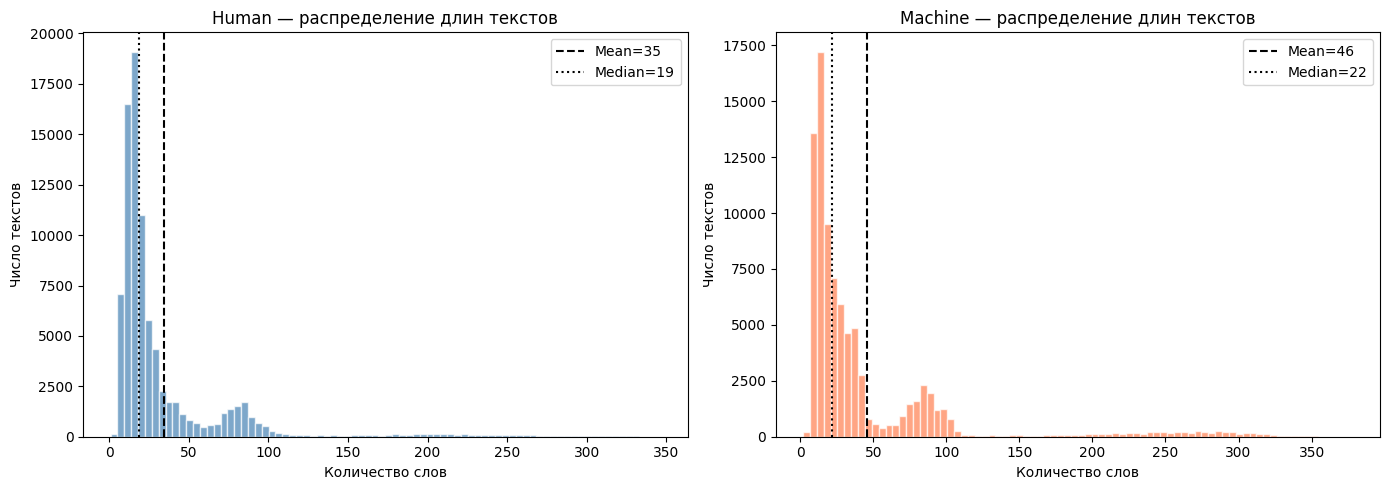

In [6]:
# Распределение длин текстов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, subset, color) in zip(axes, [
    ("Human", human, "steelblue"),
    ("Machine", machine, "coral"),
]):
    lengths = subset["n_words"].clip(upper=500)
    ax.hist(lengths, bins=80, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(subset["n_words"].mean(), color="black", ls="--", label=f"Mean={subset['n_words'].mean():.0f}")
    ax.axvline(subset["n_words"].median(), color="black", ls=":", label=f"Median={subset['n_words'].median():.0f}")
    ax.set_title(f"{name} — распределение длин текстов")
    ax.set_xlabel("Количество слов")
    ax.set_ylabel("Число текстов")
    ax.legend()

plt.tight_layout()
plt.show()

**Распределение длин.** В обоих классах большинство текстов короткие, но различия заметны:
- **Human:** Mean=35, Median=19. Распределение имеет «горб» в районе 150–200 слов — это, вероятно, полноценные статьи или посты.
- **Machine:** Mean=46, Median=22. Распределение более равномерное, с длинным хвостом до 300+ слов.

Медианы близки (19 vs 22), но средние различаются сильнее (35 vs 46) — машинные тексты чаще бывают длинными.

## 3. Закон Ципфа: human vs machine

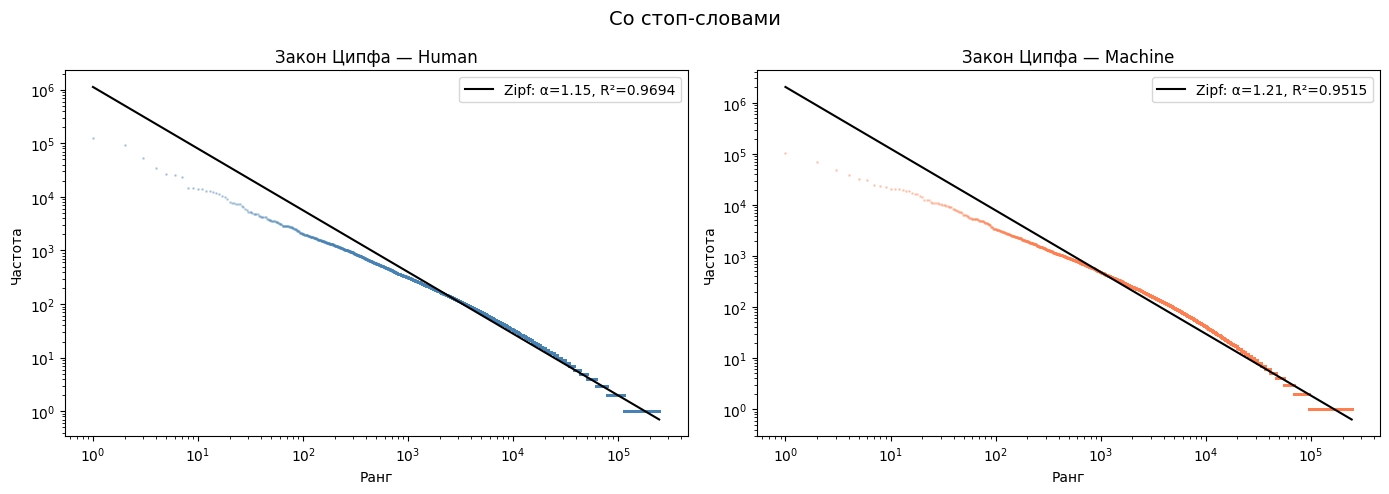

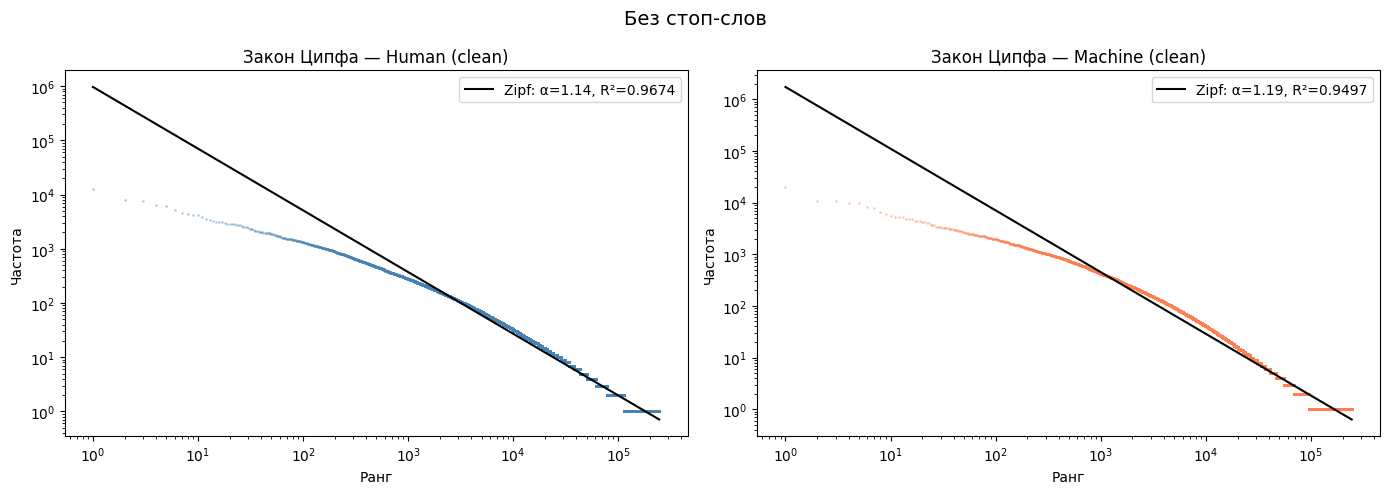

In [7]:
def zipf_plot(freq_series, label, color, ax):
    """Строит log-log график частота vs ранг и подгоняет Zipf: f = C * r^(-alpha)."""
    freqs = freq_series.values
    ranks = np.arange(1, len(freqs) + 1)
    log_r = np.log10(ranks)
    log_f = np.log10(freqs)
    alpha, log_c = np.polyfit(log_r, log_f, 1)
    c = 10 ** log_c
    r2 = np.corrcoef(log_r, log_f)[0, 1] ** 2
    ax.scatter(ranks, freqs, s=1, alpha=0.3, color=color)
    ax.plot(ranks, c * ranks ** alpha, color="black", lw=1.5,
            label=f"Zipf: α={-alpha:.2f}, R²={r2:.4f}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Ранг"); ax.set_ylabel("Частота")
    ax.set_title(f"Закон Ципфа — {label}")
    ax.legend()

# Со стоп-словами
human_freq = human["words"].explode().value_counts()
machine_freq = machine["words"].explode().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Со стоп-словами", fontsize=14)
zipf_plot(human_freq, "Human", "steelblue", axes[0])
zipf_plot(machine_freq, "Machine", "coral", axes[1])
plt.tight_layout()
plt.show()

# Без стоп-слов
human_freq_clean = human["words_clean"].explode().value_counts()
machine_freq_clean = machine["words_clean"].explode().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Без стоп-слов", fontsize=14)
zipf_plot(human_freq_clean, "Human (clean)", "steelblue", axes[0])
zipf_plot(machine_freq_clean, "Machine (clean)", "coral", axes[1])
plt.tight_layout()
plt.show()

**Закон Ципфа.** Оба корпуса подчиняются закону Ципфа (f ∝ r^(−α)), но с разными параметрами:
- **Human:** α=1.15, R²=0.9694
- **Machine:** α=1.21, R²=0.9515

У машинных текстов α выше — частотные слова доминируют сильнее, а редкие слова встречаются ещё реже. Это отражает более предсказуемый, шаблонный выбор слов у генеративных моделей. При этом R² у machine ниже — реальное распределение хуже ложится на степенной закон, особенно в области высокочастотных слов (верхняя часть графика отклоняется от прямой сильнее, чем в human).

In [8]:
# Сравнение топ-30 слов
print(f"{'Ранг':<5s} {'Human':>20s} {'freq':>10s}    {'Machine':>20s} {'freq':>10s}")
print("-" * 70)
for i in range(30):
    hw, hf = human_freq.index[i], human_freq.iloc[i]
    mw, mf = machine_freq.index[i], machine_freq.iloc[i]
    print(f"{i+1:<5d} {hw:>20s} {hf:>10,}    {mw:>20s} {mf:>10,}")

Ранг                 Human       freq                 Machine       freq
----------------------------------------------------------------------
1                        в    126,944                       в    103,187
2                        и     92,588                       и     70,504
3                       на     53,473                      на     49,100
4                        с     34,448                       с     38,787
5                       по     26,441                      по     32,369
6                       не     25,404                      не     30,698
7                      что     23,817                     что     25,063
8                       из     14,681                       а     23,458
9                       от     14,394                       я     22,857
10                       а     14,108                     для     20,472
11                       к     14,025                     это     20,265
12                      за     13,112                

Топ-30 слов совпадают по составу (служебные слова), но у machine частоты заметно выше при меньшем корпусе — генеративные модели сильнее «налегают» на частотные слова. Это согласуется с более высоким α в законе Ципфа: машинный текст лексически беднее, концентрация на топовых словах выше.

## 4. Закон Хипса: рост словаря

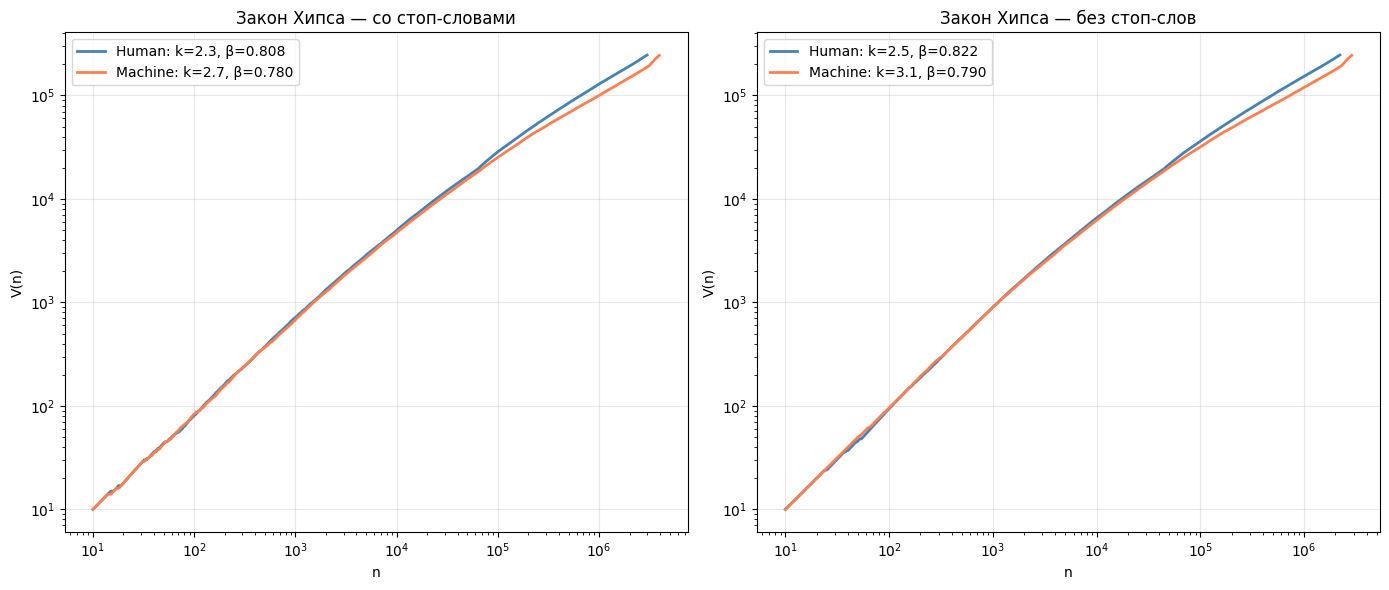

                                              Human              Machine
------------------------------------------------------------------------
Со стоп-словами                    k=2.32, β=0.8077     k=2.69, β=0.7802
Без стоп-слов                      k=2.53, β=0.8221     k=3.10, β=0.7902


In [9]:
def vocab_growth(words, num_points=500):
    """Рост словаря: V(n) — число уникальных слов после n токенов."""
    n = len(words)
    sample_points = np.unique(np.logspace(1, np.log10(n), num=num_points, dtype=int))
    vocab = set()
    sizes, counts = [], []
    prev = 0
    for target in sample_points:
        vocab.update(words[prev:target])
        prev = target
        counts.append(target)
        sizes.append(len(vocab))
    return np.array(counts), np.array(sizes)

def heaps_params(counts, sizes):
    """Подгонка V = k * n^beta."""
    log_n = np.log10(counts)
    log_v = np.log10(sizes)
    beta, log_k = np.polyfit(log_n, log_v, 1)
    k = 10 ** log_k
    r2 = np.corrcoef(log_n, log_v)[0, 1] ** 2
    return k, beta, r2

# Собираем все слова в один список
human_words = [w for words in human["words"] for w in words]
machine_words = [w for words in machine["words"] for w in words]
human_words_clean = [w for words in human["words_clean"] for w in words]
machine_words_clean = [w for words in machine["words_clean"] for w in words]

# Со стоп-словами
h_counts, h_sizes = vocab_growth(human_words)
m_counts, m_sizes = vocab_growth(machine_words)
h_k, h_beta, h_r2 = heaps_params(h_counts, h_sizes)
m_k, m_beta, m_r2 = heaps_params(m_counts, m_sizes)

# Без стоп-слов
hc_counts, hc_sizes = vocab_growth(human_words_clean)
mc_counts, mc_sizes = vocab_growth(machine_words_clean)
hc_k, hc_beta, hc_r2 = heaps_params(hc_counts, hc_sizes)
mc_k, mc_beta, mc_r2 = heaps_params(mc_counts, mc_sizes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(h_counts, h_sizes, color="steelblue", lw=2, label=f"Human: k={h_k:.1f}, β={h_beta:.3f}")
axes[0].plot(m_counts, m_sizes, color="coral", lw=2, label=f"Machine: k={m_k:.1f}, β={m_beta:.3f}")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Закон Хипса — со стоп-словами")
axes[0].set_xlabel("n"); axes[0].set_ylabel("V(n)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hc_counts, hc_sizes, color="steelblue", lw=2, label=f"Human: k={hc_k:.1f}, β={hc_beta:.3f}")
axes[1].plot(mc_counts, mc_sizes, color="coral", lw=2, label=f"Machine: k={mc_k:.1f}, β={mc_beta:.3f}")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("Закон Хипса — без стоп-слов")
axes[1].set_xlabel("n"); axes[1].set_ylabel("V(n)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'':30s} {'Human':>20s} {'Machine':>20s}")
print("-" * 72)
print(f"{'Со стоп-словами':<30s} {'k=%.2f, β=%.4f' % (h_k, h_beta):>20s} {'k=%.2f, β=%.4f' % (m_k, m_beta):>20s}")
print(f"{'Без стоп-слов':<30s} {'k=%.2f, β=%.4f' % (hc_k, hc_beta):>20s} {'k=%.2f, β=%.4f' % (mc_k, mc_beta):>20s}")

**Закон Хипса.** β у human выше (0.808 vs 0.780) — словарь человеческих текстов растёт быстрее. Генеративные модели раньше «исчерпывают» свой лексикон и чаще переиспользуют уже встреченные слова.

## 5. Анализ коллокаций

In [10]:
def bigram_stats(words, top_n=30, min_freq=10):
    """Вычисляет PMI, t-test, chi-squared для биграмм."""
    N = len(words)
    unigram_freq = Counter(words)
    bigram_freq = Counter(zip(words[:-1], words[1:]))

    # Фильтруем редкие биграммы
    bigram_freq = {bg: f for bg, f in bigram_freq.items() if f >= min_freq}

    results = []
    for (w1, w2), obs in bigram_freq.items():
        f1 = unigram_freq[w1]
        f2 = unigram_freq[w2]
        expected = f1 * f2 / N

        # PMI
        pmi = np.log2(obs / expected) if expected > 0 else 0

        # t-test
        t = (obs - expected) / np.sqrt(obs) if obs > 0 else 0

        # Chi-squared
        o11 = obs
        o12 = f1 - obs
        o21 = f2 - obs
        o22 = N - f1 - f2 + obs
        chi2 = (N * (o11 * o22 - o12 * o21) ** 2) / max((o11 + o12) * (o21 + o22) * (o11 + o21) * (o12 + o22), 1)

        results.append((w1, w2, obs, expected, pmi, t, chi2))

    df_res = pd.DataFrame(results, columns=["w1", "w2", "obs", "expected", "PMI", "t-test", "χ²"])
    return df_res

human_bigrams = bigram_stats(human_words)
machine_bigrams = bigram_stats(machine_words)

print("HUMAN: Top-20 биграмм по PMI (freq ≥ 10)")
top_h = human_bigrams.nlargest(20, "PMI")
for _, r in top_h.iterrows():
    print(f"  {r['w1']} {r['w2']:20s}  freq={r['obs']:>6.0f}  PMI={r['PMI']:.2f}  t={r['t-test']:.2f}  χ²={r['χ²']:.0f}")

print(f"\nMACHINE: Top-20 биграмм по PMI (freq ≥ 10)")
top_m = machine_bigrams.nlargest(20, "PMI")
for _, r in top_m.iterrows():
    print(f"  {r['w1']} {r['w2']:20s}  freq={r['obs']:>6.0f}  PMI={r['PMI']:.2f}  t={r['t-test']:.2f}  χ²={r['χ²']:.0f}")

HUMAN: Top-20 биграмм по PMI (freq ≥ 10)
  боко харам                 freq=    11  PMI=17.81  t=3.32  χ²=2523195
  возрастному диапазону             freq=    10  PMI=17.79  t=3.16  χ²=2259058
  столбики термометров           freq=    10  PMI=17.67  t=3.16  χ²=2085283
  улан удэ                   freq=    13  PMI=17.51  t=3.61  χ²=2422840
  human rights                freq=    12  PMI=17.48  t=3.46  χ²=2190824
  rights watch                 freq=    10  PMI=17.44  t=3.16  χ²=1774972
  верховную раду                  freq=    13  PMI=17.42  t=3.61  χ²=2280319
  ha aretz                 freq=    14  PMI=17.42  t=3.74  χ²=2455729
  los angeles               freq=    16  PMI=17.42  t=4.00  χ²=2806550
  приморско ахтарского            freq=    14  PMI=17.42  t=3.74  χ²=2455729
  описном отд                   freq=    11  PMI=17.42  t=3.32  χ²=1929500
  хип хоп                   freq=    14  PMI=17.41  t=3.74  χ²=2435265
  саудовская аравия                freq=    14  PMI=17.34  t=3.74  χ²=23

**Коллокации (PMI).** Топ-биграммы по PMI — это в основном имена собственные и устойчивые выражения (Los Angeles, Human Rights, Саудовская Аравия). Качественно списки похожи: и люди, и модели воспроизводят одни и те же именованные сущности. Это значит, что PMI топовых биграмм малополезен для классификации — он ловит специфику тем, а не стиля генерации.

In [11]:
# Статистика биграмм: со стоп-словами и без
for label, hw, mw in [
    ("Со стоп-словами", human_words, machine_words),
    ("Без стоп-слов", human_words_clean, machine_words_clean),
]:
    h_bi = list(zip(hw[:-1], hw[1:]))
    m_bi = list(zip(mw[:-1], mw[1:]))
    h_unique = len(set(h_bi))
    m_unique = len(set(m_bi))

    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")
    print(f"{'Метрика':<30s} {'Human':>15s} {'Machine':>15s}")
    print("-" * 62)
    print(f"{'Уникальных биграмм':<30s} {h_unique:>15,} {m_unique:>15,}")
    print(f"{'Bigram TTR':<30s} {h_unique/len(h_bi):>15.4%} {m_unique/len(m_bi):>15.4%}")


  Со стоп-словами
Метрика                                  Human         Machine
--------------------------------------------------------------
Уникальных биграмм                   1,630,597       1,752,414
Bigram TTR                            54.6821%        44.6368%

  Без стоп-слов
Метрика                                  Human         Machine
--------------------------------------------------------------
Уникальных биграмм                   1,608,677       1,815,334
Bigram TTR                            72.8532%        63.1902%


Bigram TTR у human значительно выше (54.7% vs 44.6%) — люди комбинируют слова разнообразнее. Машинные тексты чаще повторяют одни и те же словосочетания, что согласуется с более шаблонным характером генерации.

## 6. Извлечение признаков и классификация

Используем статистические признаки из техник IR для детекции машинно-сгенерированных текстов:
- **Лексические:** длина текста, средняя длина слова, TTR, доля hapax legomena
- **Частотные:** доля стоп-слов, энтропия распределения слов, Zipf-α на уровне документа
- **Коллокационные:** средний PMI биграмм, доля уникальных биграмм

In [12]:
def extract_features(words_list):
    """Извлекает признаки из списка слов одного документа."""
    words = words_list
    n = len(words)
    if n < 3:
        return [0] * 10

    freq = Counter(words)
    n_types = len(freq)

    # 1. Длина текста (слов)
    n_words = n

    # 2. Средняя длина слова
    avg_word_len = np.mean([len(w) for w in words])

    # 3. TTR — type-token ratio
    ttr = n_types / n

    # 4. Hapax ratio — доля слов, встретившихся один раз
    hapax = sum(1 for f in freq.values() if f == 1)
    hapax_ratio = hapax / n_types if n_types > 0 else 0

    # 5. Доля стоп-слов
    stopword_ratio = sum(1 for w in words if w in STOP_WORDS) / n

    # 6. Энтропия распределения слов
    probs = np.array(list(freq.values())) / n
    entropy = -np.sum(probs * np.log2(probs + 1e-12))

    # 7. Доля топ-10 слов (концентрация частотности)
    top10_freq = sum(sorted(freq.values(), reverse=True)[:10])
    top10_ratio = top10_freq / n

    # 8. Биграммы — средний PMI
    bigrams = list(zip(words[:-1], words[1:]))
    if len(bigrams) > 0:
        bigram_freq = Counter(bigrams)
        n_unique_bigrams = len(bigram_freq)
        bigram_ttr = n_unique_bigrams / len(bigrams)

        pmis = []
        for (w1, w2), bf in bigram_freq.items():
            if bf >= 2:
                expected = freq[w1] * freq[w2] / n
                if expected > 0:
                    pmis.append(np.log2(bf / expected))
        avg_pmi = np.mean(pmis) if pmis else 0
    else:
        bigram_ttr = 0
        avg_pmi = 0

    # 9. Yule's K — мера лексического разнообразия
    freq_spectrum = Counter(freq.values())
    m2 = sum(i * i * vi for i, vi in freq_spectrum.items())
    yule_k = 10000 * (m2 - n) / (n * n) if n > 1 else 0

    return [n_words, avg_word_len, ttr, hapax_ratio, stopword_ratio,
            entropy, top10_ratio, bigram_ttr, avg_pmi, yule_k]

FEATURE_NAMES = [
    "n_words", "avg_word_len", "ttr", "hapax_ratio", "stopword_ratio",
    "entropy", "top10_ratio", "bigram_ttr", "avg_pmi", "yule_k",
]

print("Извлечение признаков...")
features = df["words"].progress_apply(extract_features)
X = pd.DataFrame(features.tolist(), columns=FEATURE_NAMES)
y = df["label"].values

print(f"Матрица признаков: {X.shape}")
X.describe().round(3)

Извлечение признаков...


Токенизация: 100%|██████████| 172398/172398 [00:04<00:00, 36758.84it/s]


Матрица признаков: (172398, 10)


,n_words,avg_word_len,ttr,hapax_ratio,stopword_ratio,entropy,top10_ratio,bigram_ttr,avg_pmi,yule_k
count,172398.000,172398.000,172398.000,172398.000,172398.000,172398.000,172398.000,172398.00,172398.000,172398.000
mean,40.069,5.899,0.935,0.939,0.284,4.498,0.572,0.99,0.574,55.635
std,53.737,1.229,0.086,0.085,0.134,1.172,0.273,0.04,1.507,150.221
min,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.00,-0.415,0.000
25%,13.000,5.017,0.909,0.913,0.190,3.664,0.355,1.00,0.000,0.000
50%,20.000,5.812,0.958,0.961,0.260,4.187,0.556,1.00,0.000,15.432
75%,38.000,6.667,1.000,1.000,0.363,5.061,0.786,1.00,0.000,75.614
max,378.000,15.600,1.000,1.000,1.000,8.541,1.000,1.00,7.443,9500.000


In [13]:
# Сравнение средних признаков по классам
print(f"{'Признак':<20s} {'Human':>12s} {'Machine':>12s} {'Δ (M-H)':>12s}")
print("-" * 58)
for feat in FEATURE_NAMES:
    h_mean = X.loc[y == 0, feat].mean()
    m_mean = X.loc[y == 1, feat].mean()
    delta = m_mean - h_mean
    print(f"{feat:<20s} {h_mean:>12.4f} {m_mean:>12.4f} {delta:>+12.4f}")

Признак                     Human      Machine      Δ (M-H)
----------------------------------------------------------
n_words                   34.5935      45.5451     +10.9516
avg_word_len               5.9567       5.8409      -0.1158
ttr                        0.9264       0.9437      +0.0173
hapax_ratio                0.9355       0.9430      +0.0075
stopword_ratio             0.2711       0.2972      +0.0261
entropy                    4.3412       4.6553      +0.3141
top10_ratio                0.6062       0.5387      -0.0674
bigram_ttr                 0.9871       0.9930      +0.0059
avg_pmi                    0.8289       0.3198      -0.5092
yule_k                    55.3656      55.9048      +0.5392


### 6.1 Классификация: Logistic Regression + Random Forest

In [14]:
# Извлекаем признаки для validation set
df_val["words"] = df_val["text"].progress_apply(tokenize)
val_features = df_val["words"].progress_apply(extract_features)
X_val = pd.DataFrame(val_features.tolist(), columns=FEATURE_NAMES)
y_val = df_val["label"].values

print(f"Train: {X.shape}, Val: {X_val.shape}")

Токенизация: 100%|██████████| 24628/24628 [00:00<00:00, 39705.85it/s]

Train: (172398, 10), Val: (24628, 10)


In [15]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, n_jobs=-1, random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42,
    ),
}

results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # Cross-validation на train
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="f1", n_jobs=-1)
    print(f"CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Обучение на всём train, оценка на val
    model.fit(X, y)
    y_pred = model.predict(X_val)
    print(f"\nVal set classification report:")
    print(classification_report(y_val, y_pred, target_names=["Human", "Machine"]))

    results[name] = {
        "cv_f1": cv_scores.mean(),
        "model": model,
        "y_pred": y_pred,
    }


  Logistic Regression
CV F1: 0.5403 ± 0.1948

Val set classification report:
              precision    recall  f1-score   support

       Human       0.61      0.71      0.66     12314
     Machine       0.65      0.55      0.60     12314

    accuracy                           0.63     24628
   macro avg       0.63      0.63      0.63     24628
weighted avg       0.63      0.63      0.63     24628


  Random Forest
CV F1: 0.5056 ± 0.2413

Val set classification report:
              precision    recall  f1-score   support

       Human       0.63      0.86      0.73     12314
     Machine       0.78      0.50      0.61     12314

    accuracy                           0.68     24628
   macro avg       0.70      0.68      0.67     24628
weighted avg       0.70      0.68      0.67     24628


  Gradient Boosting
CV F1: 0.5066 ± 0.2434

Val set classification report:
              precision    recall  f1-score   support

       Human       0.63      0.85      0.72     12314
     Machin

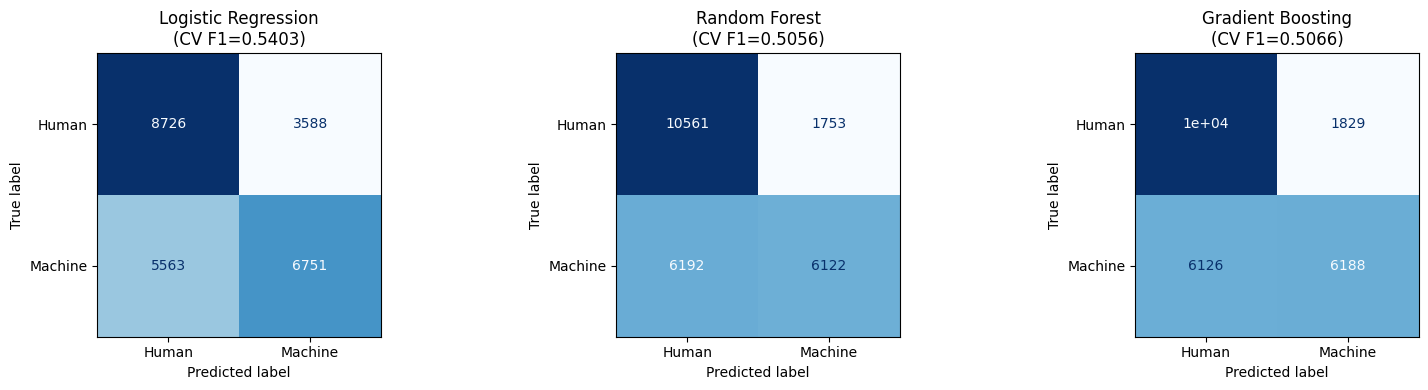

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Human", "Machine"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\n(CV F1={res['cv_f1']:.4f})")
plt.tight_layout()
plt.show()

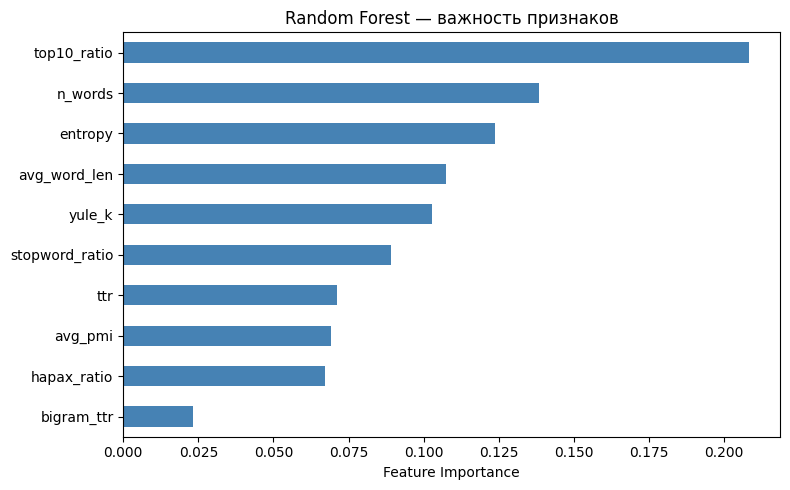

Важность признаков (Random Forest):
  top10_ratio          0.2081
  n_words              0.1382
  entropy              0.1237
  avg_word_len         0.1076
  yule_k               0.1029
  stopword_ratio       0.0890
  ttr                  0.0710
  avg_pmi              0.0693
  hapax_ratio          0.0670
  bigram_ttr           0.0232


In [17]:
# Feature importance (Random Forest)
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — важность признаков")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

print("Важность признаков (Random Forest):")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:<20s} {imp:.4f}")

### 6.2 Добавляем TF-IDF признаки

In [18]:
# TF-IDF на символьных n-граммах
tfidf_char = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), max_features=10000,
    sublinear_tf=True, dtype=np.float32,
)

# TF-IDF на словах
tfidf_word = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2), max_features=10000,
    sublinear_tf=True, dtype=np.float32,
    token_pattern=r"[а-яёА-ЯЁ]+",
)

texts_train = df["text"].values
texts_val = df_val["text"].values

X_char_train = tfidf_char.fit_transform(texts_train)
X_char_val = tfidf_char.transform(texts_val)

X_word_train = tfidf_word.fit_transform(texts_train)
X_word_val = tfidf_word.transform(texts_val)

# Комбинируем: IR-признаки + TF-IDF
from scipy.sparse import csr_matrix
X_ir_sparse = csr_matrix(X.values, dtype=np.float32)
X_ir_val_sparse = csr_matrix(X_val.values, dtype=np.float32)

X_combined_train = hstack([X_ir_sparse, X_char_train, X_word_train])
X_combined_val = hstack([X_ir_val_sparse, X_char_val, X_word_val])

print(f"IR features: {X.shape[1]}")
print(f"TF-IDF char: {X_char_train.shape[1]}")
print(f"TF-IDF word: {X_word_train.shape[1]}")
print(f"Total features: {X_combined_train.shape[1]}")

IR features: 10
TF-IDF char: 10000
TF-IDF word: 10000
Total features: 20010


In [ ]:
# Logistic Regression на комбинированных признаках (со скейлингом)
lr_combined = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=2000, random_state=42, C=1.0),
)
lr_combined.fit(X_combined_train, y)
y_pred_combined = lr_combined.predict(X_combined_val)

print("Logistic Regression (IR + TF-IDF):")
print(classification_report(y_val, y_pred_combined, target_names=["Human", "Machine"]))

# Сравнительная таблица
print("\n=== Итоговое сравнение моделей ===")
print(f"{'Модель':<40s} {'Val F1':>10s}")
print("-" * 52)
for name, res in results.items():
    f1 = f1_score(y_val, res["y_pred"])
    print(f"{name + ' (IR features only)':<40s} {f1:>10.4f}")

f1_comb = f1_score(y_val, y_pred_combined)
print(f"{'LR (IR + TF-IDF combined)':<40s} {f1_comb:>10.4f}")

Logistic Regression (IR + TF-IDF):
              precision    recall  f1-score   support

       Human       0.73      0.75      0.74     12314
     Machine       0.74      0.73      0.74     12314

    accuracy                           0.74     24628
   macro avg       0.74      0.74      0.74     24628
weighted avg       0.74      0.74      0.74     24628


=== Итоговое сравнение моделей ===
Модель                                       Val F1
----------------------------------------------------
Logistic Regression (IR features only)       0.5960
Random Forest (IR features only)             0.6065
Gradient Boosting (IR features only)         0.6087
LR (IR + TF-IDF combined)                    0.7364


## 7. Выводы

### Статистические различия human vs machine текстов

**Длина текстов.** Датасет сбалансирован (86,199 текстов в каждом классе), но машинные тексты содержат на ~31% больше слов (3,93M vs 2,98M). Медианы длин близки (19 vs 22), а средние различаются сильнее (35 vs 46) — машинные тексты чаще бывают длинными.

**Закон Ципфа.** Оба корпуса подчиняются степенному закону, но у machine α выше (1.21 vs 1.15) — частотные слова доминируют сильнее, а редкие встречаются ещё реже. Топ-30 слов совпадают по составу (служебные), но у machine частоты заметно выше — генеративные модели «налегают» на одни и те же слова.

**Закон Хипса.** β у human выше (0.808 vs 0.780) — словарь человеческих текстов растёт быстрее. Модели раньше «исчерпывают» свой лексикон.

**Коллокации.** Топ-биграммы по PMI схожи (имена собственные, устойчивые выражения) — PMI малополезен для классификации. Однако Bigram TTR у human значительно выше (54.7% vs 44.6%) — люди комбинируют слова разнообразнее.

**Влияние стоп-слов.** Удаление стоп-слов не меняет картину принципиально: все различия (Zipf-α, Heaps-β, Bigram TTR) сохраняются и в «чистом» корпусе.

### Классификация

| Модель | Val F1 |
|--------|--------|
| Logistic Regression (IR features only) | 0.5960 |
| Random Forest (IR features only) | 0.6065 |
| Gradient Boosting (IR features only) | 0.6087 |
| **LR (IR + TF-IDF combined)** | **0.7364** |

На 10 IR-признаках (TTR, hapax ratio, энтропия, Yule's K, средний PMI и др.) модели достигают F1 ≈ 0.60 — выше случайного, но недостаточно для практического применения. Добавление TF-IDF (символьные 3–5-граммы + словесные 1–2-граммы, 20k фичей) поднимает F1 до **0.74** — прирост +0.14, т.к. TF-IDF ловит конкретные стилистические паттерны, которые агрегированные статистики теряют.

### Итог

Техники IR (частотный анализ, законы Ципфа и Хипса, анализ коллокаций) выявляют устойчивые статистические различия: машинные тексты длиннее, лексически беднее, сильнее концентрированы на частотных словах и реже комбинируют слова в новые биграммы. Эти различия дают интерпретируемые признаки для классификации, а в сочетании с TF-IDF обеспечивают F1 = 0.74 на валидации.